# Aplicación de LSTM a series de tiempo

## Objetivo

En este notebook veremos una aplicación complementaria de modelos secuenciales, ahora sobre una **serie de tiempo**.

En particular, aprenderemos a:

- descargar una serie temporal simple,
- visualizarla,
- construir ventanas de tiempo,
- entrenar una red `LSTM`,
- evaluar sus predicciones,
- y discutir cómo cambia el problema al usar más de una variable.

La idea principal es mostrar que los modelos secuenciales no se usan solo en texto: también son útiles para datos ordenados en el tiempo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
!pip -q install yfinance

In [3]:
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

## Hoja de ruta

Trabajaremos en los siguientes pasos:

1. Descargar una serie temporal.
2. Visualizarla.
3. Preparar los datos.
4. Construir ventanas temporales.
5. Entrenar una LSTM univariada.
6. Evaluar sus predicciones.
7. Ver un bonus con entrada multivariada.

## 1. Descargar una serie temporal

Usaremos datos diarios de una acción bursátil solo como ejemplo de serie temporal.

Lo importante aquí no es el contexto financiero, sino la idea de trabajar con una secuencia numérica ordenada en el tiempo.

In [4]:
ticker = "HMC"   # Honda Motor Co.
start_date = "2018-01-01"
end_date = "2025-12-31"

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,HMC,HMC,HMC,HMC,HMC
Date,,,,,
2018-01-02,27.184631,27.184631,26.877149,27.050602,414900
2018-01-03,27.429041,27.460578,27.153093,27.153093,404200
2018-01-04,27.957281,28.012470,27.641916,27.665568,550300
2018-01-05,28.083424,28.099192,27.902088,28.051889,337400
2018-01-08,28.225342,28.225342,28.051892,28.051892,287100


In [5]:
print("Shape:", df.shape)
print("Columnas:", list(df.columns))

Shape: (2010, 5)
Columnas: [('Close', 'HMC'), ('High', 'HMC'), ('Low', 'HMC'), ('Open', 'HMC'), ('Volume', 'HMC')]


Para comenzar de forma simple, usaremos solo la columna `Close`, es decir, el precio de cierre diario.

In [6]:
series = df[["Close"]].dropna().copy()
series.head()

Price,Close
Ticker,HMC
Date,
2018-01-02,27.184631
2018-01-03,27.429041
2018-01-04,27.957281
2018-01-05,28.083424
2018-01-08,28.225342


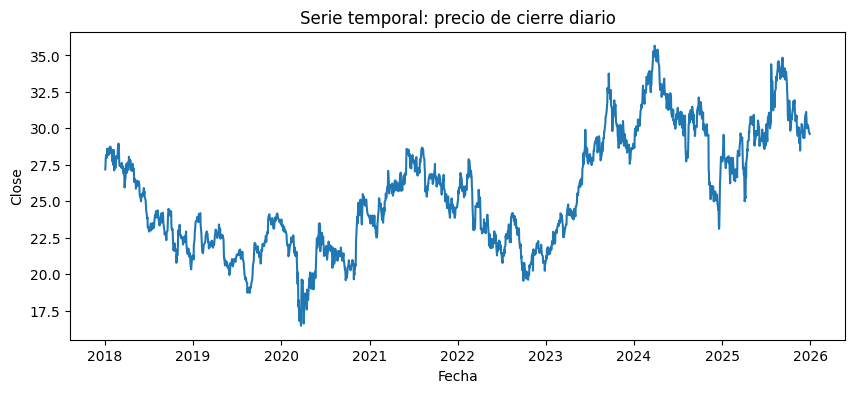

In [7]:
plt.figure(figsize=(10,4))
plt.plot(series.index, series["Close"])
plt.title("Serie temporal: precio de cierre diario")
plt.xlabel("Fecha")
plt.ylabel("Close")
plt.show()

## 2. Escalamiento

Como en otros problemas de deep learning, es conveniente escalar los datos antes de entrenar.

Usaremos `MinMaxScaler` para llevar los valores al rango `[0, 1]`.

In [8]:
scaler = MinMaxScaler()

series_scaled = scaler.fit_transform(series)
series_scaled[:5]

array([[0.55810344],
       [0.57083526],
       [0.59835243],
       [0.60492346],
       [0.61231628]])

## 3. Construcción de ventanas temporales

Para entrenar una LSTM, no le pasamos toda la serie completa de una vez.

En cambio, construimos ejemplos del tipo:

- entrada: últimos `window_size` valores,
- salida: el valor siguiente.

Por ejemplo, si `window_size = 20`, la red observará 20 días consecutivos para intentar predecir el día siguiente.

In [9]:
window_size = 20

In [10]:
def create_sequences(data, window_size=20):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

In [11]:
X_all, y_all = create_sequences(series_scaled, window_size=window_size)

print("Shape de X_all:", X_all.shape)
print("Shape de y_all:", y_all.shape)

Shape de X_all: (1990, 20, 1)
Shape de y_all: (1990, 1)


### Observación

La entrada `X_all` tiene tres dimensiones:

- número de ejemplos,
- largo de la ventana,
- número de variables.

Eso es exactamente el formato que esperan muchas capas recurrentes en Keras:

`(batch, timesteps, features)`

In [12]:
print("Primer ejemplo X:")
print(X_all[0].flatten())

print("\nPrimer valor objetivo y:")
print(y_all[0])

Primer ejemplo X:
[0.55810344 0.57083526 0.59835243 0.60492346 0.61231628 0.6008166
 0.63202998 0.62422681 0.61765538 0.60944126 0.63408351 0.61478026
 0.6303874  0.62792302 0.63983345 0.63408351 0.61642344 0.62915496
 0.62135159 0.61354852]

Primer valor objetivo y:
[0.59137045]


## 4. Separación en entrenamiento y test

En series de tiempo no conviene mezclar aleatoriamente los datos como en muchos problemas supervisados tradicionales.

Aquí respetaremos el orden temporal:
- primera parte para entrenamiento,
- última parte para test.

In [13]:
train_size = int(len(X_all) * 0.8)

X_train = X_all[:train_size]
y_train = y_all[:train_size]

X_test = X_all[train_size:]
y_test = y_all[train_size:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (1592, 20, 1)
y_train: (1592, 1)
X_test : (398, 20, 1)
y_test : (398, 1)


## 5. Modelo LSTM univariado

Construiremos ahora una red simple con:

- una capa `LSTM`,
- y una capa `Dense` final para la predicción numérica.

Como la salida es un valor continuo, este es un problema de **regresión**.

In [14]:
lstm_model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.LSTM(32),
    layers.Dense(1)
])

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

Usaremos `metrics="mae"` porque es una métrica muy interpretable en problemas de regresión:

- mide el error absoluto promedio entre predicción y valor real.

In [16]:
history_lstm_ts = lstm_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    shuffle=False
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0392 - mae: 0.1411 - val_loss: 0.0474 - val_mae: 0.2082
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065 - mae: 0.0666 - val_loss: 0.0037 - val_mae: 0.0482
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - mae: 0.0499 - val_loss: 0.0026 - val_mae: 0.0415
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0029 - mae: 0.0412 - val_loss: 0.0021 - val_mae: 0.0374
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - mae: 0.0375 - val_loss: 0.0020 - val_mae: 0.0370
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - mae: 0.0360 - val_loss: 0.0021 - val_mae: 0.0375
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - mae: 0.0355 - val_loss: 0.0021 - val_mae: 0.0371
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - mae: 0.0352 - val_loss: 0.0021 - val_mae: 0.0364
Epoch 9/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - mae:

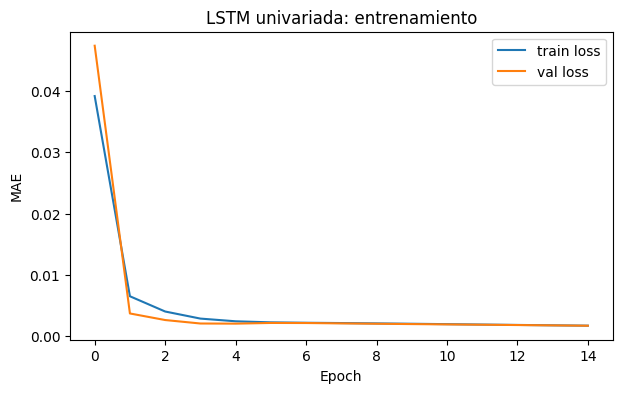

In [17]:
plt.figure(figsize=(7,4))
plt.plot(history_lstm_ts.history["loss"], label="train loss")
plt.plot(history_lstm_ts.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("LSTM univariada: entrenamiento")
plt.legend()
plt.show()

## 6. Predicción sobre el conjunto de test

In [18]:
y_pred_scaled = lstm_model.predict(X_test, verbose=0)

In [19]:
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred_scaled)

In [20]:
mae_value = mean_absolute_error(y_test_inv, y_pred_inv)
print("MAE en test:", round(mae_value, 4))

MAE en test: 0.7908


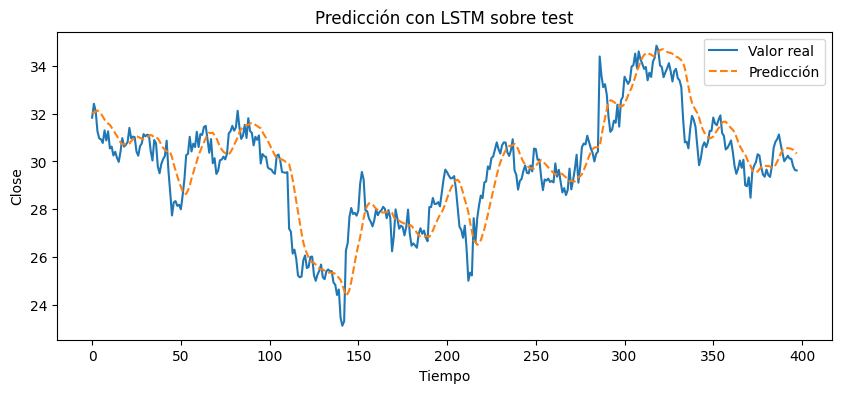

In [21]:
plt.figure(figsize=(10,4))
plt.plot(y_test_inv, label="Valor real")
plt.plot(y_pred_inv, label="Predicción", linestyle="--")
plt.title("Predicción con LSTM sobre test")
plt.xlabel("Tiempo")
plt.ylabel("Close")
plt.legend()
plt.show()

### Interpretación

El modelo no “adivina” perfectamente la serie, pero sí puede capturar parte de su evolución local.

Esto es esperable: en series reales, la predicción suele ser más difícil que en ejemplos didácticos muy limpios.

Lo importante aquí es entender el pipeline:

- serie temporal,
- ventanas,
- tensor 3D,
- LSTM,
- predicción.

## 7. Bonus opcional: entrada multivariada

Hasta ahora usamos una sola variable: `Close`.

Pero en muchos problemas de series de tiempo podemos usar varias variables al mismo tiempo.

Por ejemplo:

- `Open`
- `High`
- `Low`
- `Close`
- `Volume`

Eso transforma la entrada en una secuencia donde cada paso temporal tiene más de una característica.

In [22]:
features = df[["Open", "High", "Low", "Close", "Volume"]].dropna().copy()
features.head()

Price,Open,High,Low,Close,Volume
Ticker,HMC,HMC,HMC,HMC,HMC
Date,,,,,
2018-01-02,27.050602,27.184631,26.877149,27.184631,414900
2018-01-03,27.153093,27.460578,27.153093,27.429041,404200
2018-01-04,27.665568,28.012470,27.641916,27.957281,550300
2018-01-05,28.051889,28.099192,27.902088,28.083424,337400
2018-01-08,28.051892,28.225342,28.051892,28.225342,287100


In [23]:
feature_scaler = MinMaxScaler()
features_scaled = feature_scaler.fit_transform(features)

target_scaler = MinMaxScaler()
target_close_scaled = target_scaler.fit_transform(features[["Close"]])

In [24]:
def create_multivariate_sequences(features_data, target_data, window_size=20):
    X, y = [], []
    for i in range(window_size, len(features_data)):
        X.append(features_data[i-window_size:i])
        y.append(target_data[i])
    return np.array(X), np.array(y)

In [25]:
X_multi, y_multi = create_multivariate_sequences(
    features_scaled,
    target_close_scaled,
    window_size=window_size
)

print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

X_multi shape: (1990, 20, 5)
y_multi shape: (1990, 1)


In [26]:
train_size_multi = int(len(X_multi) * 0.8)

X_train_multi = X_multi[:train_size_multi]
y_train_multi = y_multi[:train_size_multi]

X_test_multi = X_multi[train_size_multi:]
y_test_multi = y_multi[train_size_multi:]

Ahora cada paso temporal ya no tiene una sola variable, sino varias.

La forma de la entrada será:

- `window_size` pasos de tiempo,
- y `5` características por paso.

In [27]:
multi_lstm_model = keras.Sequential([
    layers.Input(shape=(window_size, X_train_multi.shape[2])),
    layers.LSTM(32),
    layers.Dense(1)
])

multi_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
multi_lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [29]:
history_multi_lstm = multi_lstm_model.fit(
    X_train_multi,
    y_train_multi,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    shuffle=False
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0080 - mae: 0.0601 - val_loss: 0.0014 - val_mae: 0.0302
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - mae: 0.0280 - val_loss: 0.0012 - val_mae: 0.0284
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0014 - mae: 0.0290 - val_loss: 0.0011 - val_mae: 0.0276
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - mae: 0.0293 - val_loss: 0.0011 - val_mae: 0.0270
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - mae: 0.0297 - val_loss: 0.0010 - val_mae: 0.0261
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - mae: 0.0296 - val_loss: 9.7139e-04 - val_mae: 0.0253
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - mae: 0.0288 - val_loss: 9.3013e-04 - val_mae: 0.0246
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - mae: 0.0275 - val_loss: 9.1216e-04 - val_mae: 0.0243
Epoch 9/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0

In [30]:
y_pred_multi_scaled = multi_lstm_model.predict(X_test_multi, verbose=0)

y_test_multi_inv = target_scaler.inverse_transform(y_test_multi)
y_pred_multi_inv = target_scaler.inverse_transform(y_pred_multi_scaled)

mae_multi = mean_absolute_error(y_test_multi_inv, y_pred_multi_inv)
print("MAE en test (multivariado):", round(mae_multi, 4))

MAE en test (multivariado): 0.5368


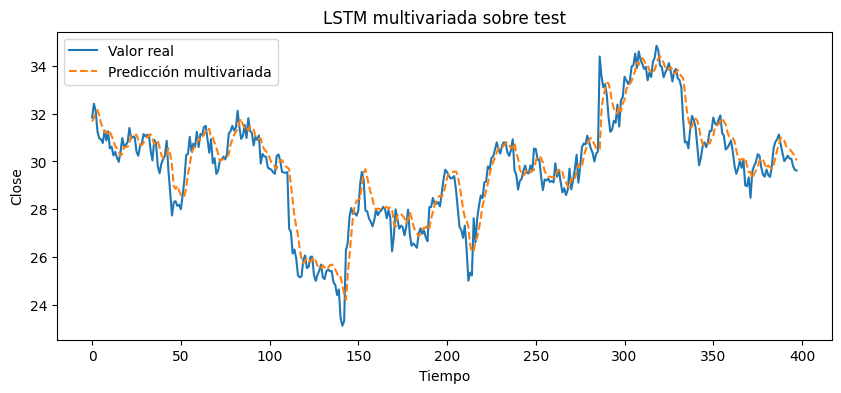

In [31]:
plt.figure(figsize=(10,4))
plt.plot(y_test_multi_inv, label="Valor real")
plt.plot(y_pred_multi_inv, label="Predicción multivariada", linestyle="--")
plt.title("LSTM multivariada sobre test")
plt.xlabel("Tiempo")
plt.ylabel("Close")
plt.legend()
plt.show()

### Comentario sobre el bonus

En algunos casos, usar más variables puede ayudar al modelo, porque dispone de más contexto por cada paso temporal.

Sin embargo, también aumenta la complejidad del problema y no garantiza automáticamente mejores resultados.

In [32]:
print("MAE univariado   :", round(mae_value, 4))
print("MAE multivariado :", round(mae_multi, 4))

MAE univariado   : 0.7908
MAE multivariado : 0.5368


## Conclusión

En este notebook vimos una aplicación de `LSTM` a series de tiempo.

Primero trabajamos con una entrada **univariada** y luego vimos, como extensión, una versión **multivariada**.

La idea central es que una serie temporal también puede verse como una secuencia, por lo que los modelos recurrentes son una herramienta natural para este tipo de datos.